In [117]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq

In [118]:
a = 0.3              #Associated with Reynolds-stress
eta = 5*10**(-3)
c = 9.65             #Associated with dissapation
d = 0.05             #Turbulent diffusivity coefficient
kappa = 0.09
alpha = 0.01         #Drag coefficient
alpha_0 = 0.03       #Drag coefficient in the zero nodes  
beta = np.pi/2

#a and c are dictate the onset of sustained turbulence.
    #Not possible to get this to form at the same Re as WF so has been scaled. 


def A(q):  #Reynolds-stress closure 
    return a * (np.sqrt(q**2 + eta**2) - eta)

def eps0(q, Re): #Closure for \eps_0 dissapation term
    return (c/Re) * q

def v_t (q, Re): #turbulent difusivity (closure?)
    return d*Re*q

#The above functions constitute the turbulrence closures


def u_dot (q, u, Re): 
    return (alpha+(beta**2)/Re)*(1-u)-beta*A(q)

def q_dot (q, Re): 
    return 1/2 *beta*u*A(q)- 2*alpha*q - eps(q,Re)

In [119]:
def u_nullcline(q, Re, alpha, beta):
    return 1 - (beta*Re*A(q))/(alpha*Re + beta**2)

def q_nullcline(q, Re, alpha, beta):
    return (4*alpha*q + 2*eps0(q, Re))/(beta*A(q))

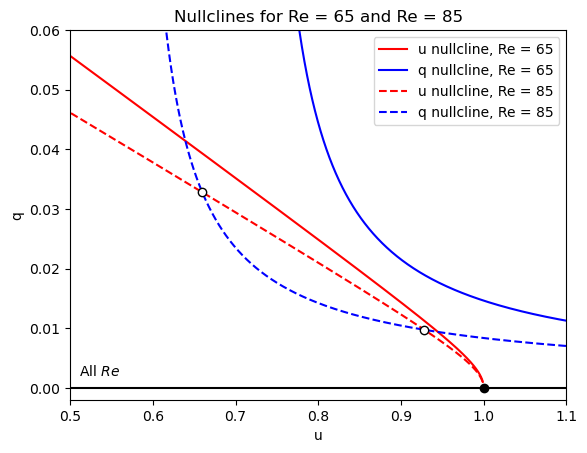

In [120]:
q_pos = np.linspace(1e-3, 0.06, 800)
q_axis1 = np.linspace(1e-3, 0.06, 800)
u_vals = np.linspace(0.5, 1.1, 800)

Re = [65, 85] 

linesu = ['r', 'r--']
linesq = ['b', 'b--']

def find_fp(q, Re, alpha, beta):
    all_fp_q = []
    all_fp_u = []

    for r in Re:
        roots = []
        u_nc = u_nullcline(q, r, alpha, beta)
        q_nc = q_nullcline(q, r, alpha, beta)
        f = u_nc - q_nc

        for i in range(len(q)-1):
            if f[i] * f[i+1] < 0:
                roots.append(brentq(lambda x: u_nullcline(x, r, alpha, beta) - q_nullcline(x, r, alpha, beta), q[i], q[i+1]))

        fp_q = np.array(roots)
        fp_u = u_nullcline(fp_q, r, alpha, beta)
        all_fp_q.append(fp_q)
        all_fp_u.append(fp_u)

    return all_fp_q, all_fp_u

plt.figure ()
for i in range (len(Re)): 
    u_nc = u_nullcline(q_axis1, Re[i], alpha, beta)
    q_nc = q_nullcline(q_axis1, Re[i], alpha, beta)
    plt.plot(u_nc, q_axis1, linesu[i], label = f'u nullcline, Re = {Re[i]}')
    plt.plot(q_nc, q_axis1, linesq[i], label = f'q nullcline, Re = {Re[i]}')
    plt.xlabel('u')
    plt.ylabel('q')

plt.plot(u_vals, np.zeros_like(u_vals), 'k', zorder=3)

fp1x, fp1y = np.array([1]), np.array([0])
plt.scatter(fp1x, fp1y, c= 'k', zorder=2)

all_fp_q, all_fp_u = find_fp(q_pos, Re, alpha, beta)
for fp_q, fp_u in zip(all_fp_q, all_fp_u):
    plt.scatter(fp_u, fp_q, c='w', edgecolors='k', zorder=2)

plt.title('Nullclines for Re = 65 and Re = 85')
plt.xlim(0.5, 1.1)
plt.ylim(-0.002, 0.06)
plt.text(0.51, 0.002, r"All $Re$")
plt.legend() 
plt.show()

In [121]:
def q_Jacobian(q, u, Re, alpha, beta, a, c, eta): 
    dAdq = a*q/np.sqrt(q**2 + eta**2)
    deps_dq = c/Re

    J_11 = 1/2 * beta* u * dAdq - 2*alpha - deps_dq
    J_12 = 1/2 * beta * A(q)
    J_21 = -beta* dAdq 
    J_22 = - (alpha + (beta**2)/Re)

    return np.array ([[J_11, J_12], [J_21, J_22]])

def bifurcation(q, Re_vals, alpha, beta, a, c, eta):
    q_stable = []
    Re_stable = []
    q_unstable = []
    Re_unstable = []

    for Re in Re_vals:
        all_fp_q, all_fp_u = find_fp(q, [Re], alpha, beta)  # find FPs for this Re only
        fp_q, fp_u = all_fp_q[0], all_fp_u[0]               # unpack single-Re result

        for q_i, u_i in zip(fp_q, fp_u):
            J = q_Jacobian(q_i, u_i, Re, alpha, beta, a, c, eta)
            eigvals = np.linalg.eigvals(J)
            if np.all(np.real(eigvals) < 0):
                Re_stable.append(Re)
                q_stable.append(q_i)
            else:
                Re_unstable.append(Re)
                q_unstable.append(q_i)

    return Re_stable, q_stable, Re_unstable, q_unstable

/var/folders/yt/llp6tnmn43jfqwk2w114dq080000gn/T/ipykernel_85999/1552650035.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*alpha*q + 2*eps0(q, Re))/(beta*A(q))


Text(0, 0.5, 'q')

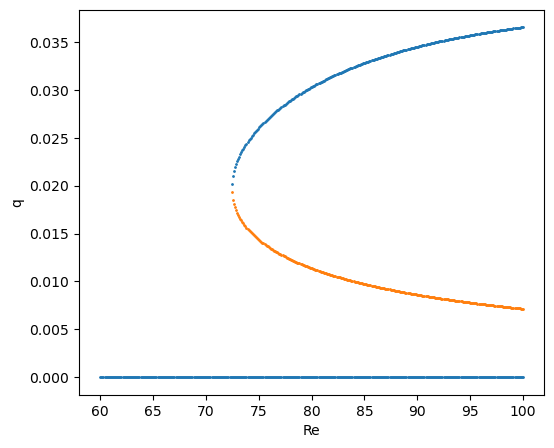

In [126]:
q_axis2 = np.linspace(-0.005, 0.04, 400)
Re_vals = np.linspace(60,100, 400)

re_s, q_s, re_us, q_us = bifurcation(q_axis2, Re_vals, alpha, beta, a, c, eta)

plt.figure(figsize=(6,5))
plt.scatter(re_s, q_s,s=1,label='stable')
plt.scatter(re_us, q_us, s=1, label='unstable')

plt.xlabel("Re")
plt.ylabel("q")


In [ ]:
def figure_6(q1, u1, q2, u2, Re_vals, alpha_vals, beta, a, c):
    n = len(alpha_vals) -1 
    fig,axes = plt.subplots(2, n, figsize=(5*n, 10))
    for i, alpha in 

In [123]:
print(f"Re_stable length: {len(re_s)}")
print(f"Re_unstable length: {len(re_us)}")
print(f"First few stable points: {list(zip(re_s[:5], q_s[:5]))}")
print(f"First few unstable points: {list(zip(re_us[:5], q_us[:5]))}")

Re_stable length: 676
Re_unstable length: 276
First few stable points: [(np.float64(60.0), np.float64(-1.1255661997652504e-12)), (np.float64(60.100250626566414), np.float64(-1.239029106938992e-12)), (np.float64(60.200501253132835), np.float64(-6.608547445287163e-13)), (np.float64(60.30075187969925), np.float64(3.370281395647054e-14)), (np.float64(60.40100250626566), np.float64(1.4609485785291547e-12))]
First few unstable points: [(np.float64(72.43107769423558), np.float64(0.019328709022487223)), (np.float64(72.531328320802), np.float64(0.0185222832796819)), (np.float64(72.63157894736842), np.float64(0.018073571196318593)), (np.float64(72.73182957393483), np.float64(0.017727814432039284)), (np.float64(72.83208020050125), np.float64(0.017437721962085935))]
